# Cell Accumulation Plots

Plot of mutant kinetics for Figure 4.

## Initialize Environment

In [1]:
# Load R Packages
library(ggplot2)
library(cowplot)
library(ggpubr)
library(ggsci)
library(ggprism)
library(tidyr)
library(dplyr)
library(gridExtra)
library(grid)

# Set working directory
setwd("/home/dalbao/AlbaoRunx3Manuscript/flow/Fig04")

# Load flow processing functions (plot_padj for multiple-hypothesis-corrected comparisons)
source("/home/dalbao/AlbaoRunx3Manuscript/flow/scripts/flowProcessing.R")

# Load processed data
total_norm <- read.csv("NormalizedCellCounts.csv")

head(total_norm)


Attaching package: ‘ggpubr’




The following object is masked from ‘package:cowplot’:

    get_legend





Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




...


Attaching package: ‘rstatix’




The following object is masked from ‘package:stats’:

    filter





Attaching package: ‘purrr’




The following objects are masked from ‘package:rlang’:

    %@%, flatten, flatten_chr, flatten_dbl, flatten_int, flatten_lgl,
    flatten_raw, invoke, splice




,ID,Group,Population,Population1Deriv,Population2Deriv,Timepoint,TimepointStr,Percent,PercentOfTotal,TotalCells,TheoreticalCells,RawCount,TheoreticalCount,NormalizationFactor,NormalizedRealCount,NormalizedTheoreticalCount
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Day6_A1,mock,Transferred,NA,NA,6,Day6,10.212830,10.2128304,70298000,94256528,7179415.5,9626259.3,1.00,7179415.5,9626259.3
2,Day6_A1,mock,Transferred,Transduced,NA,6,Day6,76.874147,7.8510263,70298000,94256528,5519114.5,7400104.8,0.76,7261992.7,9736979.9
3,Day6_A1,mock,Transferred,Transduced,DP,6,Day6,2.839123,0.2229003,70298000,94256528,156694.4,210098.1,0.76,206176.9,276444.8
4,Day6_A1,mock,Transferred,Transduced,EE,6,Day6,23.962814,1.8813268,70298000,94256528,1322535.1,1773273.3,0.76,1740177.8,2333254.4
5,Day6_A1,mock,Transferred,Transduced,MP,6,Day6,3.022354,0.2372858,70298000,94256528,166807.2,223657.4,0.76,219483.1,294286.0
6,Day6_A1,mock,Transferred,Transduced,Neg,6,Day6,10.630316,0.8345889,70298000,94256528,586699.3,786654.5,0.76,771972.8,1035071.7


## Inspect Data

In [2]:
table(total_norm$Group)


  AD   ID mock   VW   WT 
 152  152  152  152  152 

In [3]:
# Rename Group then Factorize
total_norm$Group <- gsub("AD", "dAD", total_norm$Group)
total_norm$Group <- gsub("ID", "dID", total_norm$Group)
total_norm$Group <- gsub("VW", "dVWRPY", total_norm$Group)
total_norm$Group <- gsub("WT", "Runx3-WT", total_norm$Group)
total_norm$Group <- factor(total_norm$Group, levels = c("mock", "Runx3-WT", "dAD", "dID", "dVWRPY"))


## Theme Settings

In [4]:
# Create a default theme
colors <- c("mock" = "#808180",
            "Runx3-WT" = "#00A087",
            "dAD" = "#3C5488",
            "dID"= "#F39B7F",
            "dVWRPY" = "#4DBBD5")

# Use ggprism, base 12, not bold, and remove legend
theme <- theme_bw(      base_size = 14,
                        base_family = "sans"
                        ) +
    theme(  axis.text = element_text(size = 10, color = "black"),
            axis.title = element_text(size = 12, color = "black"),
            axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, color = "black"),
            axis.text.y = element_text(size = 10, color = "black"),
            # axis.title.x = element_blank(),
            strip.text = element_text(size = 12),
            legend.position = "none",
            plot.title = element_text(size = 12),  # Set main title size
            panel.grid = element_blank())  # Remove gridlines

## Plot Numbers

In [5]:
# Subset total transduced
subset <- total_norm %>% filter(Population1Deriv == "Transduced" & is.na(Population2Deriv))

head(subset)

,ID,Group,Population,Population1Deriv,Population2Deriv,Timepoint,TimepointStr,Percent,PercentOfTotal,TotalCells,TheoreticalCells,RawCount,TheoreticalCount,NormalizationFactor,NormalizedRealCount,NormalizedTheoreticalCount
,<chr>,<fct>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Day6_A1,mock,Transferred,Transduced,NA,6,Day6,76.87415,7.851026,70298000,94256528,5519114,7400105,0.760,7261993,9736980
2,Day6_A10,dAD,Transferred,Transduced,NA,6,Day6,76.05068,12.250998,76942000,98439298,9426163,12059797,0.745,12652568,16187647
3,Day6_A11,dAD,Transferred,Transduced,NA,6,Day6,74.32939,9.405896,90090000,106716700,8473772,10037662,0.745,11374191,13473372
4,Day6_A12,dAD,Transferred,Transduced,NA,6,Day6,69.88233,8.238010,83878000,102805898,6909878,8469160,0.745,9275004,11368000
5,Day6_A2,mock,Transferred,Transduced,NA,6,Day6,72.89792,4.004118,88434000,105674155,3541002,4231318,0.760,4659213,5567523
6,Day6_A3,mock,Transferred,Transduced,NA,6,Day6,72.39609,3.629593,129498000,131526243,4700250,4773867,0.760,6184540,6281404


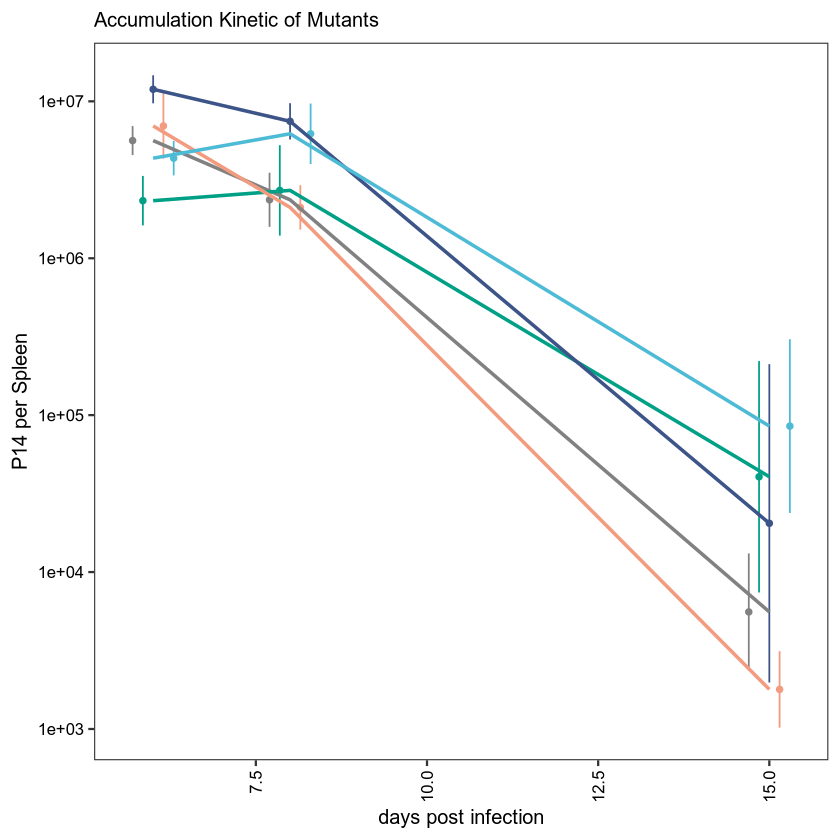

In [6]:
# helper function for mean ± SEM
mean_se <- function(x) {
    m <- mean(x, na.rm = TRUE)
    se <- sd(x, na.rm = TRUE) / sqrt(length(x))
    ymin <- m - se
    ymax <- m + se
    return(data.frame(y = m, ymin = ymin, ymax = ymax))
}

p1 <- ggplot(subset, aes(x = Timepoint, y = NormalizedRealCount, fill = Group, color = Group, group = Group)) +
    scale_y_log10() +
    stat_summary(
        fun.data = mean_sdl,              # mean ± SD
        fun.args = list(mult = 1),        # mult=1 → mean ± 1 SD
        geom = "pointrange",              # point with vertical error bar
        position = position_dodge(width = 0.75),  # dodge to separate groups
        size = 0.2
    ) +
    # Optionally, connect the means with lines
    stat_summary(
        fun = mean,
        geom = "line",
        aes(group = Group),
        linewidth = 1
    ) +
    
    scale_fill_manual(values = colors) +
    scale_color_manual(values = colors) +
    labs(
            title = paste0("Accumulation Kinetic of Mutants")
        ) +
    ylab("P14 per Spleen") + xlab("days post infection") +
    theme

print(p1)

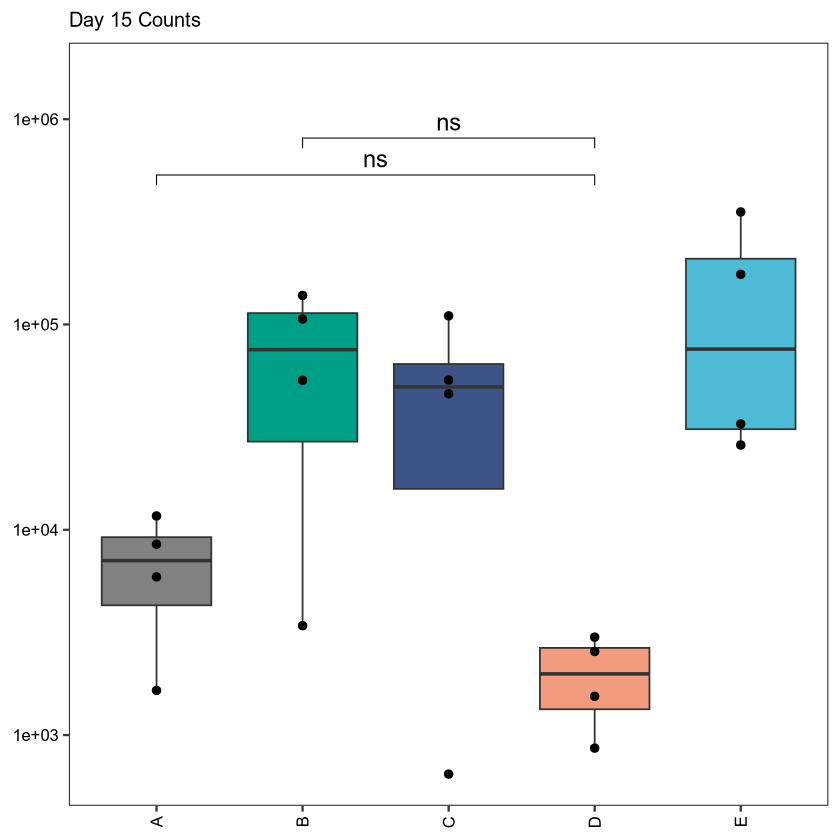

In [7]:
subset <- subset %>% filter(Timepoint == 15)

# BH-adjusted pairwise comparisons via plot_padj(), replacing the unadjusted
# stat_compare_means() p-values used previously
stat.test <- plot_padj(
    data            = subset,
    comparisons     = list(
        c("mock", "dID"),
        c("Runx3-WT", "dID")
    ),
    p_adjust_method = "BH",
    y_col           = "NormalizedRealCount",
    x_col           = "Group",
    paired          = FALSE
)

# Save comparison statistics (p, p.adj, fold changes, effect sizes) to CSV
write.csv(stat.test, "2025-017-Day15Counts-stats.csv", row.names = FALSE)

stat.test <- stat.test %>%
    # geom_bracket()'s y.position aesthetic bypasses scale_y_log10()'s data
    # transform, so it must be supplied already in log10 units. plot_padj()
    # spaces brackets in linear space, which collapses to a sliver once the
    # counts (10^2 - 10^5 here) are logged, so space them in log10 units.
    mutate(y.position = log10(max(subset$NormalizedRealCount, na.rm = TRUE)) +
                        row_number() * 0.18)

p2 <- ggplot(subset, aes(x = Group, y = NormalizedRealCount, fill = Group)) +
        # log transform, with extra top headroom so the significance
        # brackets drawn above the data are not clipped
        scale_y_log10(expand = expansion(mult = c(0.05, 0.15))) +
        geom_boxplot(outliers = FALSE) +
        geom_point(size=2) +
        scale_fill_manual(values = colors) +
        stat_pvalue_manual(
            stat.test,
            label = "p.adj.signif",   # BH-adjusted p-value stars
            tip.length = 0.01,
            size = 5,
            inherit.aes = FALSE
        ) +
        scale_x_discrete(labels = c("mock" = "A", 
                                "Runx3-WT" = "B", 
                                "dAD" = "C", 
                                "dID" = "D", 
                                "dVWRPY" = "E")) +
        labs(
            title = paste0("Day 15 Counts")
        ) + xlab("Groups") +
        theme +
        theme(
            axis.title.x = element_blank(),
            axis.title.y = element_blank()
        )

    print(p2)


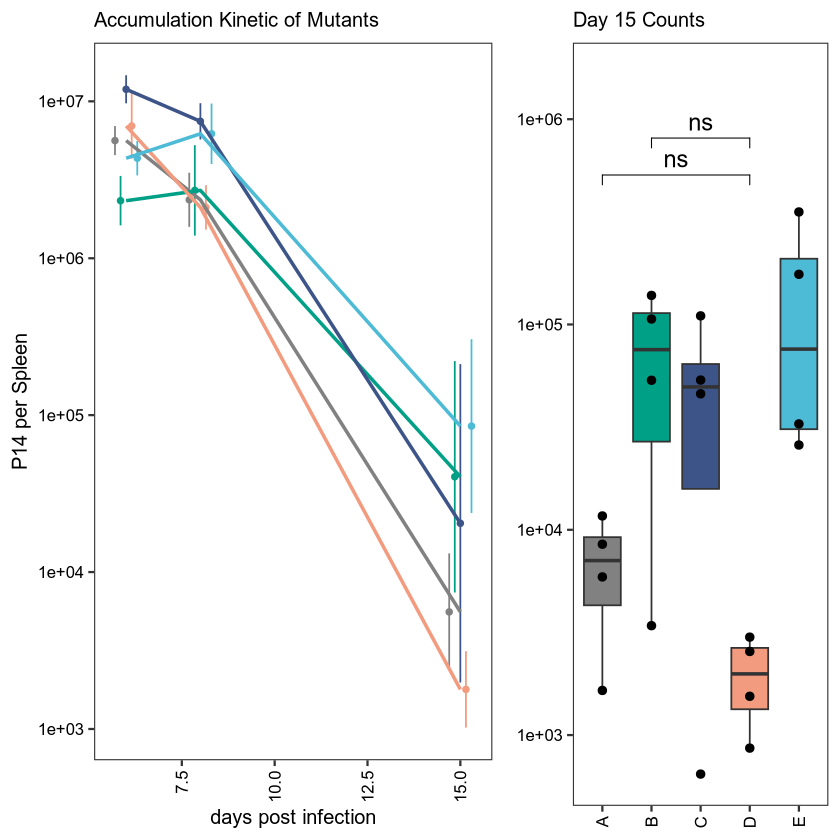

In [8]:
combined_plot <- arrangeGrob(p1, p2, ncol = 2, widths = c(3, 2))
grid.draw(combined_plot)

In [9]:
pdf(paste("accumulation.pdf"), width = 5, height = 3)
grid.draw(combined_plot)
dev.off()

pdf 
  2

## Plot Subset Freq over Time

In [10]:
# Load data
freq <- read.csv("25-017-Runx3mut_fracParent.csv")

# View data
head(freq)

,ID,Group,Population,Timepoint,TimepointStr,Percent,PercentOfTotal
,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>
1,Day6_A1,mock,DP,6,Day6,2.839123,2.839123
2,Day6_A1,mock,EE,6,Day6,23.962814,23.962814
3,Day6_A1,mock,MP,6,Day6,3.022354,3.022354
4,Day6_A1,mock,Neg,6,Day6,10.630316,10.630316
5,Day6_A1,mock,NonTerm,6,Day6,13.669065,13.669065
6,Day6_A1,mock,TE,6,Day6,70.175709,70.175709


In [11]:
# Rename Group then Factorize
freq$Group <- gsub("AD", "dAD", freq$Group)
freq$Group <- gsub("ID", "dID", freq$Group)
freq$Group <- gsub("VW", "dVWRPY", freq$Group)
freq$Group <- gsub("WT", "Runx3-WT", freq$Group)
freq$Group <- factor(freq$Group, levels = c("mock", "Runx3-WT", "dAD", "dID", "dVWRPY"))

In [12]:
subset <- freq %>% filter(Timepoint == 15 & Population %in% c("TE", "DP", "EE", "MP", "Tcm", "Tpm", "Tem"))

# Factorize Population
subset$Population <- factor(subset$Population, levels = c("TE", "EE", "DP", "MP", "Tcm", "Tpm", "Tem"))

head(subset)

,ID,Group,Population,Timepoint,TimepointStr,Percent,PercentOfTotal
,<chr>,<fct>,<fct>,<int>,<chr>,<dbl>,<dbl>
1,Panel1Batch1_A1,mock,DP,15,Day15,4.245283,4.245283
2,Panel1Batch1_A1,mock,EE,15,Day15,15.094340,15.094340
3,Panel1Batch1_A1,mock,MP,15,Day15,15.094340,15.094340
4,Panel1Batch1_A1,mock,TE,15,Day15,65.566038,65.566038
5,Panel1Batch1_A1,mock,Tcm,15,Day15,10.377358,10.377358
6,Panel1Batch1_A1,mock,Tem,15,Day15,76.886792,76.886792


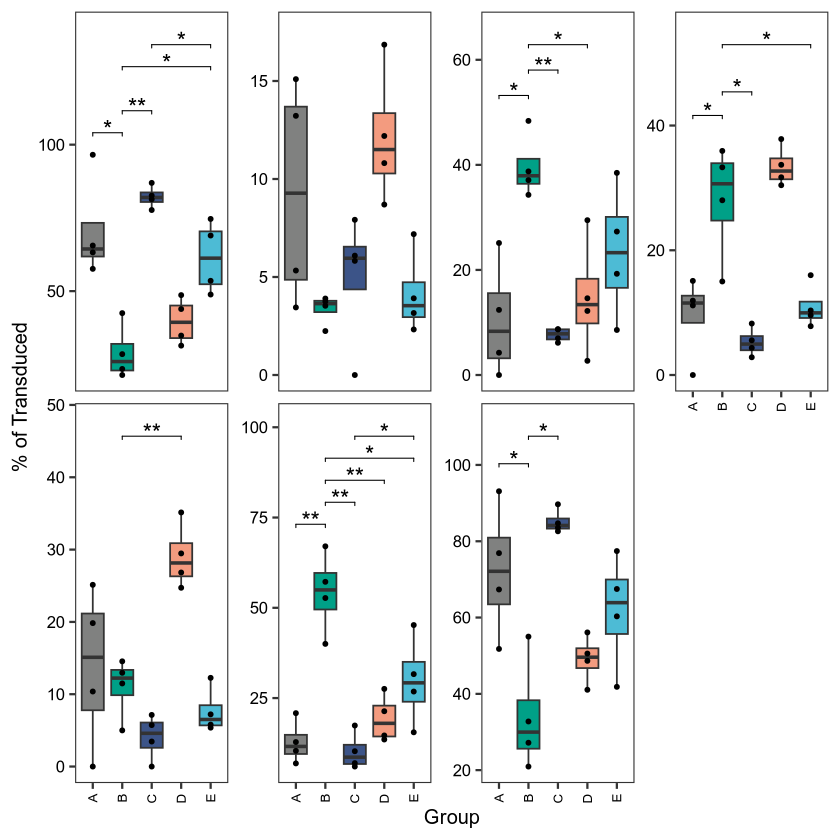

In [13]:
# BH-adjusted pairwise comparisons via plot_padj(), adjusted within each
# Population panel (adjust_scope = "intrafacet"). The three separate
# stat_compare_means() calls used previously are folded into one comparison
# list so every test enters the same correction.
stat.test <- plot_padj(
    data            = subset,
    comparisons     = list(
        c("mock", "Runx3-WT"),
        c("Runx3-WT", "dAD"),
        c("Runx3-WT", "dID"),
        c("Runx3-WT", "dVWRPY"),
        c("dAD", "dVWRPY")
    ),
    p_adjust_method = "BH",
    y_col           = "Percent",
    x_col           = "Group",
    facet_col       = "Population",
    adjust_scope    = "intrafacet",
    paired          = FALSE,
    step_fraction   = 0.1,
    min_step        = 0.5
)

# Save comparison statistics (p, p.adj, fold changes, effect sizes) to CSV
write.csv(stat.test, "2025-017-SubsetFreq-D15-stats.csv", row.names = FALSE)

# Only the significant comparisons get a bracket drawn (see stat_pvalue_manual
# below), so only these need extra headroom
stat.test.sig <- stat.test %>% filter(p.adj < 0.05)

p <- ggplot(subset, aes(x = Group, y = Percent, fill = Group)) +
    geom_boxplot(outliers = FALSE) +
    geom_point(size = 1) +
    facet_wrap(~ Population, ncol = 4, scales = "free_y") +  # Set number of columns

    scale_fill_manual(values = colors) +
    scale_x_discrete(labels = c("mock" = "A", 
                                "Runx3-WT" = "B", 
                                "dAD" = "C", 
                                "dID" = "D", 
                                "dVWRPY" = "E")) +
    ylab("% of Transduced") +
    theme + 
    # Make room for the p-value bracket: with scales = "free_y", each panel
    # auto-scales to the data alone, so the bracket drawn at y.position
    # (above the tallest box, per plot_padj()'s step_fraction/min_step) would
    # get clipped at the top of the panel without this. geom_blank() is
    # invisible but still trains the y-scale, and a small multiplier adds
    # headroom for the label text sitting above the bracket line itself.
    geom_blank( data = stat.test.sig, aes(x = group1, y = y.position),
                inherit.aes = FALSE) +
    scale_y_continuous(expand = expansion(mult = c(0.05, 0.10))) +
    stat_pvalue_manual(
        stat.test.sig,
        label = "p.adj.signif",   # BH-adjusted p-value stars
        tip.length = 0.01,
        size = 5,
        inherit.aes = FALSE
    ) +
    theme(  strip.text = element_blank(),
            axis.text = element_text(size = 8))

print(p)


In [14]:
head(freq)

,ID,Group,Population,Timepoint,TimepointStr,Percent,PercentOfTotal
,<chr>,<fct>,<chr>,<int>,<chr>,<dbl>,<dbl>
1,Day6_A1,mock,DP,6,Day6,2.839123,2.839123
2,Day6_A1,mock,EE,6,Day6,23.962814,23.962814
3,Day6_A1,mock,MP,6,Day6,3.022354,3.022354
4,Day6_A1,mock,Neg,6,Day6,10.630316,10.630316
5,Day6_A1,mock,NonTerm,6,Day6,13.669065,13.669065
6,Day6_A1,mock,TE,6,Day6,70.175709,70.175709


In [15]:
# Isolate observations wherein Population in c("DP", "MP")
subset <- freq %>% filter(Population %in% c("DP", "MP")) %>%
    # Remove PercentOfTotal
    select(-PercentOfTotal) %>%
    # Spread Percent by Population
    pivot_wider(names_from = Population, values_from = Percent) %>%
    # Add DP and MP to CD127Pos
    mutate(CD127Pos = DP + MP)

head(subset)

ID,Group,Timepoint,TimepointStr,DP,MP,CD127Pos
<chr>,<fct>,<int>,<chr>,<dbl>,<dbl>,<dbl>
Day6_A1,mock,6,Day6,2.839123,3.0223542,5.861477
Day6_A10,dAD,6,Day6,6.426830,0.8334026,7.260232
Day6_A11,dAD,6,Day6,6.821651,1.0276877,7.849339
Day6_A12,dAD,6,Day6,4.914991,0.8860616,5.801053
Day6_A2,mock,6,Day6,5.171965,5.4120566,10.584022
Day6_A3,mock,6,Day6,2.288481,2.9419546,5.230435


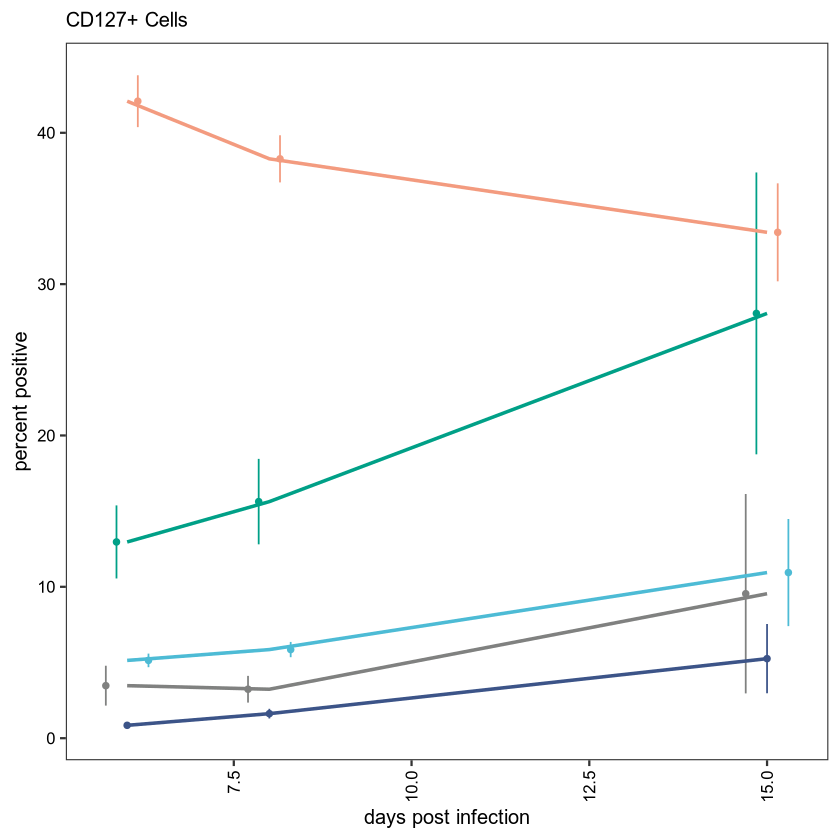

In [16]:
p1 <- ggplot(subset, aes(x = Timepoint, y = MP, fill = Group, color = Group, group = Group)) +
    stat_summary(
        fun.data = mean_sdl,              # mean ± SD
        fun.args = list(mult = 1),        # mult=1 → mean ± 1 SD
        geom = "pointrange",              # point with vertical error bar
        position = position_dodge(width = 0.75),  # dodge to separate groups
        size = 0.2
    ) +
    # Optionally, connect the means with lines
    stat_summary(
        fun = mean,
        geom = "line",
        aes(group = Group),
        linewidth = 1
    ) +
    scale_fill_manual(values = colors) +
    scale_color_manual(values = colors) +
    labs(
            title = paste0("CD127+ Cells")
        ) +
    ylab("percent positive") + xlab("days post infection") +
    theme

print(p1)

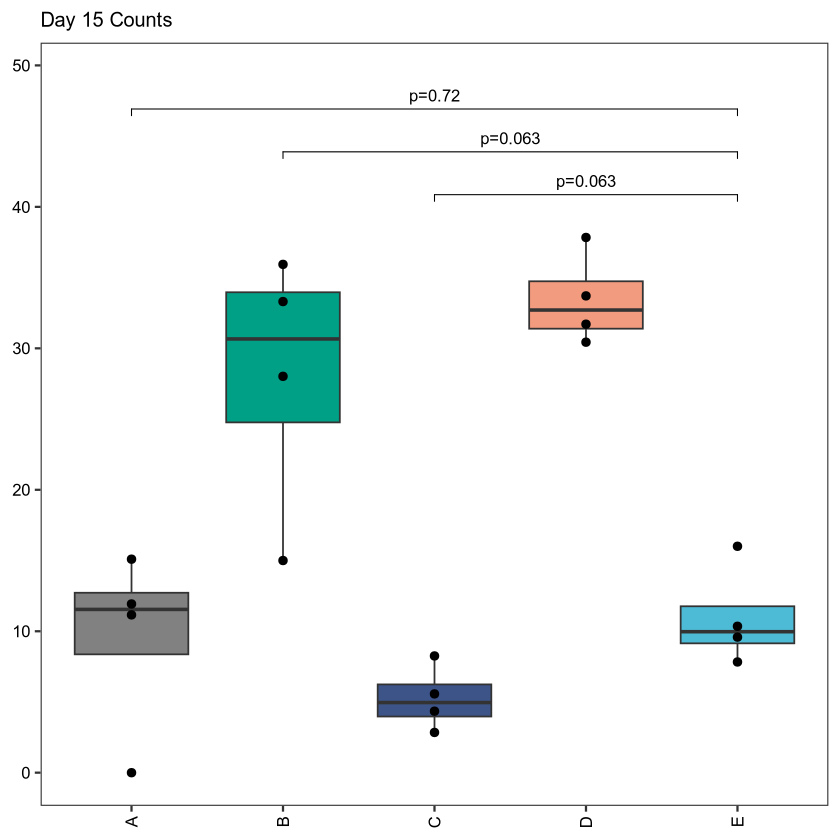

In [17]:
subset <- subset %>% filter(Timepoint == 15)

# BH-adjusted pairwise comparisons via plot_padj(), replacing the unadjusted
# stat_compare_means() p-values used previously
stat.test <- plot_padj(
    data            = subset,
    comparisons     = list(
        c("dAD", "dVWRPY"),
        c("Runx3-WT", "dVWRPY"),
        c("mock", "dVWRPY")
    ),
    p_adjust_method = "BH",
    y_col           = "MP",
    x_col           = "Group",
    paired          = FALSE
)

# Save comparison statistics (p, p.adj, fold changes, effect sizes) to CSV
write.csv(stat.test, "2025-017-MP-D15-stats.csv", row.names = FALSE)

# Numeric labels, as before, but showing the adjusted p-value
stat.test <- stat.test %>%
    mutate(p.adj.label = paste0("p=", signif(p.adj, 2)))

p2 <- ggplot(subset, aes(x = Group, y = MP, fill = Group)) +
        geom_boxplot(outliers = FALSE) +
        geom_point(size=2) +
        scale_fill_manual(values = colors) +
        scale_y_continuous(expand = expansion(mult = c(0.05, 0.10))) +
        stat_pvalue_manual(
            stat.test,
            label = "p.adj.label",
            tip.length = 0.01,
            size = 3.5,   # numeric labels are wider than stars, so smaller
            inherit.aes = FALSE
        ) +
        scale_x_discrete(labels = c("mock" = "A", 
                                "Runx3-WT" = "B", 
                                "dAD" = "C", 
                                "dID" = "D", 
                                "dVWRPY" = "E")) +
        labs(
            title = paste0("Day 15 Counts")
        ) + xlab("Groups") +
        theme +
        theme(
            axis.title.x = element_blank(),
            axis.title.y = element_blank()
        )

    print(p2)


In [18]:
ls()

[1] "add_population_derivatives" "colors"                    
 [3] "combined_plot"              "combinePercents"           
 [5] "compute_percent_of_total"   "finalize_flow_table"       
 [7] "freq"                       "load_workspace_cached"     
 [9] "mean_se"                    "p"                         
[11] "p1"                         "p2"                        
[13] "plot_padj"                  "stat.test"                 
[15] "stat.test.sig"              "subset"                    
[17] "theme"                      "total_norm"

## Re-Challenge